In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

In [2]:
import pandas as pd

df = pd.read_csv("/content/ABC (1).csv")

In [3]:
df.shape

(405893, 22)

In [4]:
df.head()

,time,instance_events_type,scheduling_class,collection_type,priority,collections_events_type,vertical_scaling,scheduler,start_time,end_time,...,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,event,rr_cpu,rr_memory,au_cpu,au_memory,mu_cpu,mu_memory
0,0,2,3,1,200,2,1.0,0.0,274800000000,275100000000,...,2.184993,0.010722,1.0,2,0.020660,0.014435,0.004662,5.920410e-03,0.011902,5.935669e-03
1,2517305308183,2,2,0,360,2,2.0,0.0,1800713000000,1800714000000,...,2.184993,0.010722,1.0,2,0.007240,0.001303,0.000000,9.536743e-07,0.000000,9.536743e-07
2,195684022913,6,2,0,103,6,2.0,1.0,81300000000,81600000000,...,0.939919,0.001318,1.0,7,0.048584,0.004166,0.024200,2.788544e-03,0.060059,2.845764e-03
3,0,2,3,0,200,2,2.0,0.0,1075500000000,1075800000000,...,1.359102,0.007643,1.0,2,0.070435,0.041626,0.047607,3.442383e-02,0.133301,3.466797e-02
4,1810627494172,3,2,0,0,3,3.0,0.0,1565315000000,1565317000000,...,1.160684,0.007771,1.0,3,0.002449,0.000232,0.000271,7.629395e-05,0.000415,7.629395e-05


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405893 entries, 0 to 405892
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             405893 non-null  int64  
 1   instance_events_type             405893 non-null  int64  
 2   scheduling_class                 405893 non-null  int64  
 3   collection_type                  405893 non-null  int64  
 4   priority                         405893 non-null  int64  
 5   collections_events_type          405893 non-null  int64  
 6   vertical_scaling                 405893 non-null  float64
 7   scheduler                        405893 non-null  float64
 8   start_time                       405893 non-null  int64  
 9   end_time                         405893 non-null  int64  
 10  assigned_memory                  405893 non-null  float64
 11  page_cache_memory                405893 non-null  float64
 12  cy

In [6]:
df.tail()

,time,instance_events_type,scheduling_class,collection_type,priority,collections_events_type,vertical_scaling,scheduler,start_time,end_time,...,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,event,rr_cpu,rr_memory,au_cpu,au_memory,mu_cpu,mu_memory
405888,0,2,1,0,117,2,1.0,0.0,456600000000,456900000000,...,0.693324,0.003158,1.000000,2,0.035950,0.015488,0.015320,0.001501,0.048340,0.001802
405889,18279167039,0,2,0,360,0,2.0,0.0,943800000000,944100000000,...,1.019433,0.001859,1.000000,0,0.021973,0.001303,0.038147,0.019989,0.091797,0.020477
405890,733307641549,3,3,0,200,3,1.0,0.0,1161300000000,1161600000000,...,0.990970,0.002941,1.000000,3,0.121460,0.082642,0.023560,0.075806,0.062500,0.075806
405891,1984523129238,2,1,0,117,2,1.0,0.0,1885800000000,1886100000000,...,3.023431,0.015743,0.996667,2,0.005669,0.001562,0.006004,0.000982,0.018433,0.001381
405892,1478177324880,5,2,0,360,5,2.0,0.0,1094700000000,1095000000000,...,2.184993,0.010722,1.000000,5,0.016296,0.001303,0.011993,0.008545,0.072021,0.012863


In [7]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [8]:
df = df.drop(columns=[
'Unnamed: 0','collection_id','alloc_collection_id','instance_index',
'machine_id','user','collection_name','collection_logical_name',
'start_after_collection_ids','cluster','constraint'
], errors='ignore')#Removing unnecessary columns

In [9]:
import ast # Splitting dictionary based columns to two separate columns

In [10]:
# df['rr_cpu'] = df['resource_request'].apply(
#     lambda x: ast.literal_eval(x)['cpus'] if pd.notnull(x) else None
# )

# df['rr_memory'] = df['resource_request'].apply(
#     lambda x: ast.literal_eval(x)['memory'] if pd.notnull(x) else None)

In [11]:
# df['au_cpu'] = df['average_usage'].apply(
#     lambda x: ast.literal_eval(x)['cpus']
# )

# df['au_memory'] = df['average_usage'].apply(
#     lambda x: ast.literal_eval(x)['memory'])

In [12]:
# df['mu_cpu'] = df['maximum_usage'].apply(
#     lambda x: ast.literal_eval(x)['cpus']
# )

# df['mu_memory'] = df['maximum_usage'].apply(
#     lambda x: ast.literal_eval(x)['memory'])

In [13]:
# df = df.drop(columns=[
# 'resource_request',
# 'average_usage',
# 'maximum_usage',
# 'random_sample_usage',
# 'cpu_usage_distribution',
# 'tail_cpu_usage_distribution'
# ], errors='ignore')

In [14]:
df[['rr_cpu','rr_memory','au_cpu','au_memory','mu_cpu','mu_memory']].head()

,rr_cpu,rr_memory,au_cpu,au_memory,mu_cpu,mu_memory
0,0.020660,0.014435,0.004662,5.920410e-03,0.011902,5.935669e-03
1,0.007240,0.001303,0.000000,9.536743e-07,0.000000,9.536743e-07
2,0.048584,0.004166,0.024200,2.788544e-03,0.060059,2.845764e-03
3,0.070435,0.041626,0.047607,3.442383e-02,0.133301,3.466797e-02
4,0.002449,0.000232,0.000271,7.629395e-05,0.000415,7.629395e-05


In [15]:
df.dtypes

,0
time,int64
instance_events_type,int64
scheduling_class,int64
collection_type,int64
priority,int64
collections_events_type,int64
vertical_scaling,float64
scheduler,float64
start_time,int64
end_time,int64


In [16]:
#Using INTERPOLATE ->Filling missing values with near values
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='polynomial', order=2)

In [17]:
# df = df[df['event'] != 'Update Running'] #It is rare class

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['event'] = le.fit_transform(df['event'])

In [19]:
dict(zip(le.classes_, le.transform(le.classes_))) #Mapping event target labels to numbers

{np.int64(0): np.int64(0),
 np.int64(1): np.int64(1),
 np.int64(2): np.int64(2),
 np.int64(3): np.int64(3),
 np.int64(4): np.int64(4),
 np.int64(5): np.int64(5),
 np.int64(6): np.int64(6),
 np.int64(7): np.int64(7),
 np.int64(8): np.int64(8)}

In [20]:
# df = df[df['event'] != 9]

In [21]:
df = df.select_dtypes(exclude=['object'])

In [22]:
df = df.fillna(df.mean())

In [23]:
df.columns

Index(['time', 'instance_events_type', 'scheduling_class', 'collection_type',
       'priority', 'collections_events_type', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'event', 'rr_cpu', 'rr_memory', 'au_cpu', 'au_memory',
       'mu_cpu', 'mu_memory'],
      dtype='object')

In [24]:
leak_cols = [
    "instance_events_type",
    "collections_events_type",
   ]

X = df.drop(columns=[c for c in leak_cols if c in df.columns] + ["event"])
y = df["event"]

In [25]:
# Normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [28]:
df['event'].value_counts()

,count
event,
3,92867
2,92678
0,75907
7,69104
5,59515
1,14756
4,951
8,111
6,4


In [29]:
## Preprocessing completed

In [30]:
np.isnan(X_train).sum()

,0
time,0
scheduling_class,0
collection_type,0
priority,0
vertical_scaling,0
scheduler,0
start_time,0
end_time,0
assigned_memory,0
page_cache_memory,0


In [31]:
#Fill remaining missing value
import numpy as np

X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

In [32]:
df.columns

Index(['time', 'instance_events_type', 'scheduling_class', 'collection_type',
       'priority', 'collections_events_type', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'event', 'rr_cpu', 'rr_memory', 'au_cpu', 'au_memory',
       'mu_cpu', 'mu_memory'],
      dtype='object')

In [33]:
feature_cols = [
'time','scheduling_class','collection_type','priority',
'vertical_scaling','scheduler','start_time','end_time',
'assigned_memory','page_cache_memory','cycles_per_instruction',
'memory_accesses_per_instruction','sample_rate',
'rr_cpu','rr_memory','au_cpu','au_memory','mu_cpu','mu_memory'
]

import pandas as pd

X_train = pd.DataFrame(X_train, columns=feature_cols)

In [34]:
import pandas as pd

X_train = pd.DataFrame(X_train, columns=feature_cols)
X_test = pd.DataFrame(X_test, columns=feature_cols)

In [35]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

k_values = [6,7,10,12,14,15,19]

for k in k_values:

    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_train, y_train)

    selected_features = X_train.columns[selector.get_support()]

    print("Selected features for K =", k)
    print(list(selected_features))
    print()

Selected features for K = 6
['collection_type', 'priority', 'vertical_scaling', 'scheduler', 'rr_cpu', 'rr_memory']

Selected features for K = 7
['collection_type', 'priority', 'vertical_scaling', 'scheduler', 'assigned_memory', 'rr_cpu', 'rr_memory']

Selected features for K = 10
['scheduling_class', 'collection_type', 'priority', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'assigned_memory', 'rr_cpu', 'rr_memory']

Selected features for K = 12
['scheduling_class', 'collection_type', 'priority', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'assigned_memory', 'rr_cpu', 'rr_memory', 'au_cpu', 'mu_cpu']

Selected features for K = 14
['scheduling_class', 'collection_type', 'priority', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'rr_cpu', 'rr_memory', 'au_cpu', 'mu_cpu']

Selected features for K = 15
['scheduling_class', 'collection_type', 'priority', 'vertical_scaling', 'scheduler

In [36]:
print("failed in features:", "failed" in X.columns)

failed in features: False


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [38]:
print("failed in features:", "failed" in X.columns)

failed in features: False


In [39]:
# Fixing null values
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [40]:
# pip install tensorflow


In [41]:
import tensorflow as tf
import numpy as np
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout, Input
from tensorflow.keras.optimizers import Adam

results = {}

for k in k_values:

    print("Testing GRU for K =", k)

    # Feature selection
    selector = SelectKBest(score_func=f_classif, k=k)

    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Reshape for GRU (samples, timesteps, features)
    X_train_gru = X_train_selected.reshape(
        (X_train_selected.shape[0], 1, X_train_selected.shape[1])
    )

    X_test_gru = X_test_selected.reshape(
        (X_test_selected.shape[0], 1, X_test_selected.shape[1])
    )

    # Build GRU model
    model = Sequential()

    model.add(Input(shape=(1, X_train_selected.shape[1])))

    model.add(Dense(128, activation='relu'))

    model.add(GRU(128))

    model.add(Dropout(0.1))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(len(np.unique(y_train)), activation='softmax'))

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train model (used 5 epochs)
    model.fit(
        X_train_gru,
        y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate model
    loss, accuracy = model.evaluate(X_test_gru, y_test, verbose=0)

    print("Accuracy:", accuracy)

    results[k] = accuracy


Testing GRU for K = 6
Accuracy: 0.7201000452041626
Testing GRU for K = 7
Accuracy: 0.737308919429779
Testing GRU for K = 10
Accuracy: 0.8550733327865601
Testing GRU for K = 12
Accuracy: 0.9180945754051208
Testing GRU for K = 14
Accuracy: 0.9445176720619202
Testing GRU for K = 15
Accuracy: 0.9500733017921448
Testing GRU for K = 19
Accuracy: 0.9557274580001831


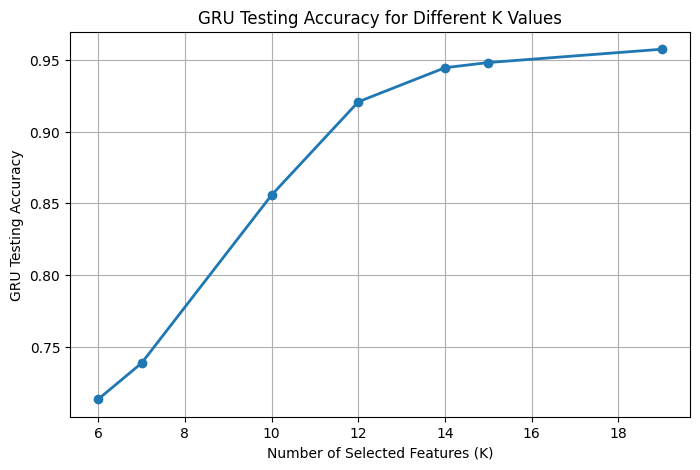

In [44]:
import matplotlib.pyplot as plt

k_values = [6,7,10,12,14,15,19]

accuracies = [
0.7132,
0.7384,
0.8558,
0.9209,
0.9447,
0.9483,
0.9576
]

plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o', linewidth=2)

plt.xlabel("Number of Selected Features (K)")
plt.ylabel("GRU Testing Accuracy")

plt.title("GRU Testing Accuracy for Different K Values")

plt.grid(True)

plt.show()

In [45]:
history = model.fit(
    X_train_gru,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
4567/4567 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9525 - loss: 0.1484 - val_accuracy: 0.9617 - val_loss: 0.1246
Epoch 2/5
4567/4567 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9587 - loss: 0.1300 - val_accuracy: 0.9666 - val_loss: 0.1110
Epoch 3/5
4567/4567 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9628 - loss: 0.1155 - val_accuracy: 0.9699 - val_loss: 0.0977
Epoch 4/5
4567/4567 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9669 - loss: 0.1039 - val_accuracy: 0.9731 - val_loss: 0.0898
Epoch 5/5
4567/4567 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9697 - loss: 0.0946 - val_accuracy: 0.9761 - val_loss: 0.0827


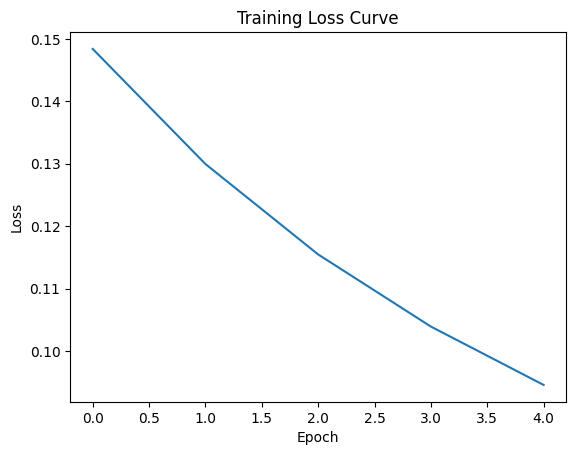

In [46]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [47]:
print("failed in X_train:", "failed" in X.columns)
print("event in X_train:", "event" in X.columns)

failed in X_train: False
event in X_train: False


In [48]:
#Select Best Features (K=19)
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=19)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [49]:
#Reshape for GRU GRU requires 3-dimensional input.

#(samples, timesteps, features)
X_train_gru = X_train_selected.reshape(
    (X_train_selected.shape[0], 1, X_train_selected.shape[1])
)

X_test_gru = X_test_selected.reshape(
    (X_test_selected.shape[0], 1, X_test_selected.shape[1])
)


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout, Input
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(1, X_train_selected.shape[1])))

model.add(GRU(128))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_train)), activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_gru,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
4059/4059 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.7026 - loss: 0.7742 - val_accuracy: 0.8020 - val_loss: 0.5501
Epoch 2/5
4059/4059 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8097 - loss: 0.5253 - val_accuracy: 0.8548 - val_loss: 0.4159
Epoch 3/5
4059/4059 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8458 - loss: 0.4328 - val_accuracy: 0.8841 - val_loss: 0.3376
Epoch 4/5
4059/4059 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.8682 - loss: 0.3766 - val_accuracy: 0.9000 - val_loss: 0.2919
Epoch 5/5
4059/4059 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8823 - loss: 0.3383 - val_accuracy: 0.9126 - val_loss: 0.2607


In [51]:
model.predict(X_train_gru[:1])   #  IMPORTANT FIX

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


array([[8.3262128e-01, 6.8696320e-22, 1.5908308e-01, 3.7982952e-04,
        1.8375342e-08, 7.9157725e-03, 1.0895524e-16, 3.4020850e-10,
        1.0182648e-12]], dtype=float32)

In [52]:
#Remove the Softmax Layer
#Now we turn GRU into a feature extractor.
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)



In [53]:
# Extract GRU feautures
X_train_features = feature_extractor.predict(X_train_gru)
X_test_features = feature_extractor.predict(X_test_gru)

10148/10148 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [54]:
#Checking shape
print(X_train_features.shape)
print(X_test_features.shape)

(324714, 64)
(81179, 64)


In [55]:
#Train ML Classifiers

In [56]:
# ******************************** ANN-RF **************************************

In [ ]:
# ANN-RF
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

ann = Sequential([
    Input(shape=(X_train_features.shape[1],)),  # explicit input
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])

In [ ]:
from tensorflow.keras.models import Model

ann_feature_extractor = Model(
    inputs=ann.layers[0].input,
    outputs=ann.layers[-2].output
)

X_train_ann_features = ann_feature_extractor.predict(X_train_features)
X_test_ann_features  = ann_feature_extractor.predict(X_test_features)

10148/10148 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step
2537/2537 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [ ]:
print(X_train_ann_features.shape)
print(X_test_ann_features.shape)

(324714, 64)
(81179, 64)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)

rf.fit(X_train_ann_features, y_train)   # use ANN features

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred_ann = rf.predict(X_test_ann_features)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, rf_pred_ann)
print("ANN + RF Accuracy:", acc)

ANN + RF Accuracy: 0.9924364675593441


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, rf_pred_ann))
print("ANN + RF RMSE:", rmse)

ANN + RF RMSE: 0.25781852646622666


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred_ann))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15181
           1       1.00      1.00      1.00      2951
           2       0.99      0.99      0.99     18536
           3       0.99      1.00      1.00     18574
           4       0.95      0.77      0.85       190
           5       0.99      1.00      1.00     11903
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00     13821
           8       1.00      0.59      0.74        22

    accuracy                           0.99     81179
   macro avg       0.99      0.92      0.95     81179
weighted avg       0.99      0.99      0.99     81179



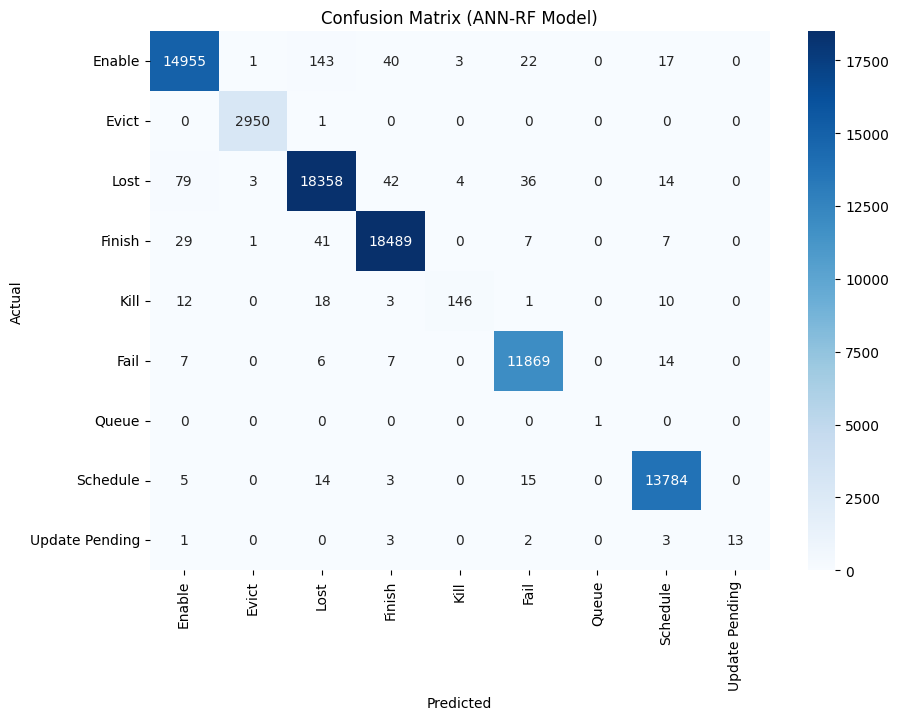

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred_ann)
labels = [
    "Enable",
    "Evict",
    "Lost",
    "Finish",
    "Kill",
    "Fail",
    "Queue",
    "Schedule",
    "Update Pending"
]
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=labels,
    yticklabels=labels)

plt.title("Confusion Matrix (ANN-RF Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

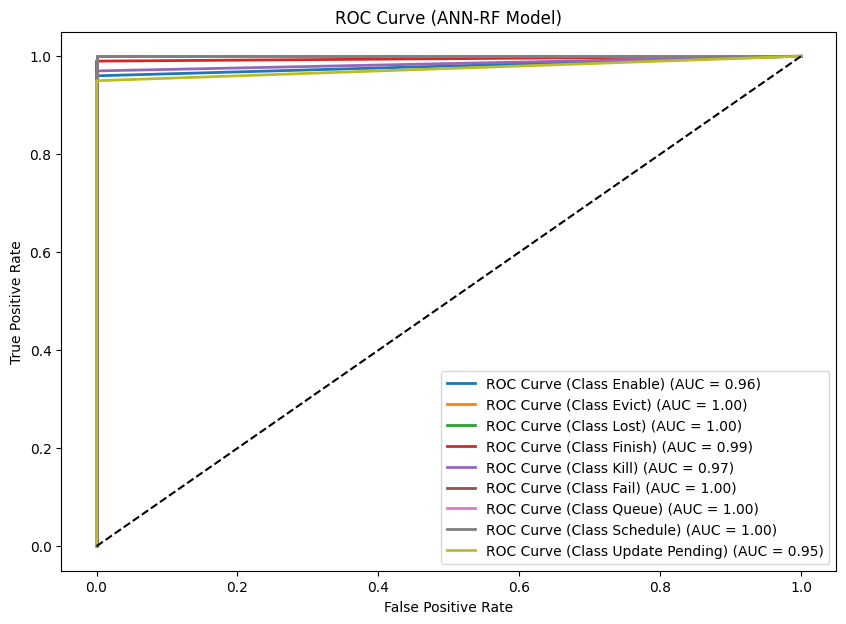

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = rf.predict_proba(X_test_ann_features)

plt.figure()
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - ANN + RF")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
# ************************************ RF-GRU ******************************************

In [57]:
#Random Forest-GRU

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)
rf.fit(X_train_features, y_train)
rf_pred = rf.predict(X_test_features)

In [58]:
from sklearn.metrics import accuracy_score

print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 0.9936190394067431


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15181
           1       1.00      1.00      1.00      2951
           2       0.99      0.99      0.99     18536
           3       0.99      1.00      1.00     18574
           4       0.93      0.82      0.87       190
           5       0.99      1.00      1.00     11903
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00     13821
           8       1.00      0.59      0.74        22

    accuracy                           0.99     81179
   macro avg       0.99      0.93      0.95     81179
weighted avg       0.99      0.99      0.99     81179



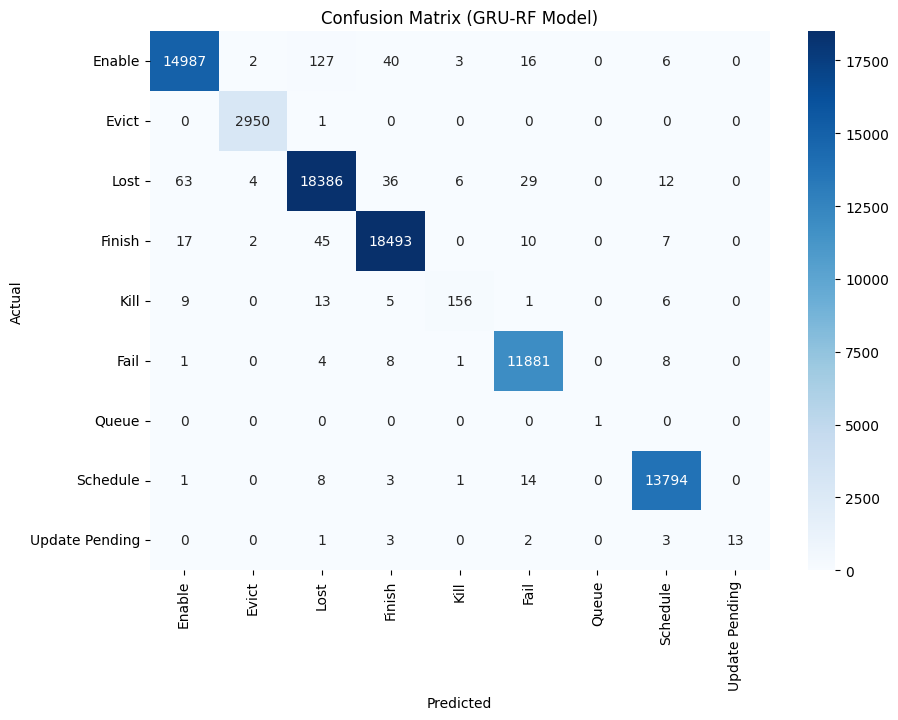

In [60]:
#Confusion Matrix of GRU-RF Model.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
labels = [
    "Enable",
    "Evict",
    "Lost",
    "Finish",
    "Kill",
    "Fail",
    "Queue",
    "Schedule",
    "Update Pending"
]
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=labels,
    yticklabels=labels)

plt.title("Confusion Matrix (GRU-RF Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

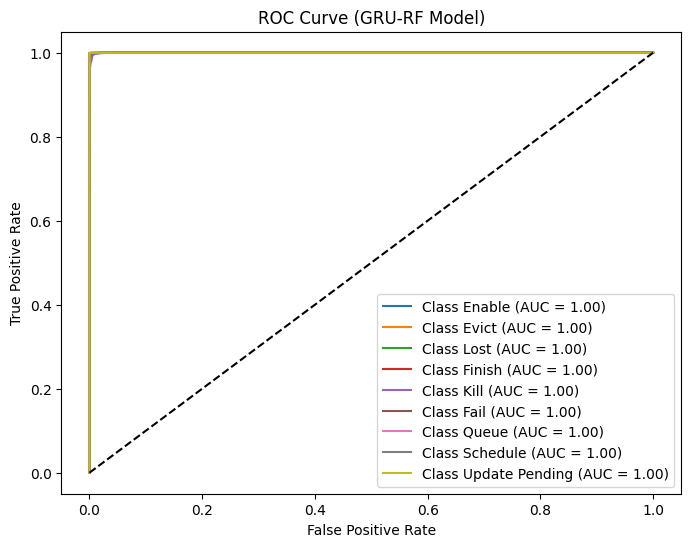

In [61]:
# ROC Curve of GRU-RF Model.
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
labels = [
    "Enable",
    "Evict",
    "Lost",
    "Finish",
    "Kill",
    "Fail",
    "Queue",
    "Schedule",
    "Update Pending"
]
classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

rf_prob = rf.predict_proba(X_test_features)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GRU-RF Model)")
plt.legend()

plt.show()

In [63]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(selector, "selector.pkl")

model.save("gru_model.h5")

print("Models Saved Successfully")

Models Saved Successfully


In [ ]:
# *********************************** ANN-SVM ************************************

In [ ]:
# ann-svm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Use ANN features instead of raw features
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_ann_features,   # changed
    y_train,
    train_size=70000,
    stratify=y_train,
    random_state=42
)

svm = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True
)

print("Training SVM...")

svm.fit(X_train_small, y_train_small)

Training SVM...


SVC(C=10, class_weight='balanced', probability=True)

In [ ]:
svm_pred_ann = svm.predict(X_test_ann_features)
svm_prob = svm.predict_proba(X_test_ann_features)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, svm_pred_ann))
print("ANN + RF RMSE:", rmse)

ANN + RF RMSE: 0.5800359390460246


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred_ann))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92     15181
           1       0.99      1.00      1.00      2951
           2       0.92      0.92      0.92     18536
           3       0.96      0.94      0.95     18574
           4       0.68      0.82      0.74       190
           5       0.96      0.99      0.97     11903
           6       0.00      0.00      0.00         1
           7       0.99      0.99      0.99     13821
           8       0.78      0.64      0.70        22

    accuracy                           0.95     81179
   macro avg       0.80      0.80      0.80     81179
weighted avg       0.95      0.95      0.95     81179



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


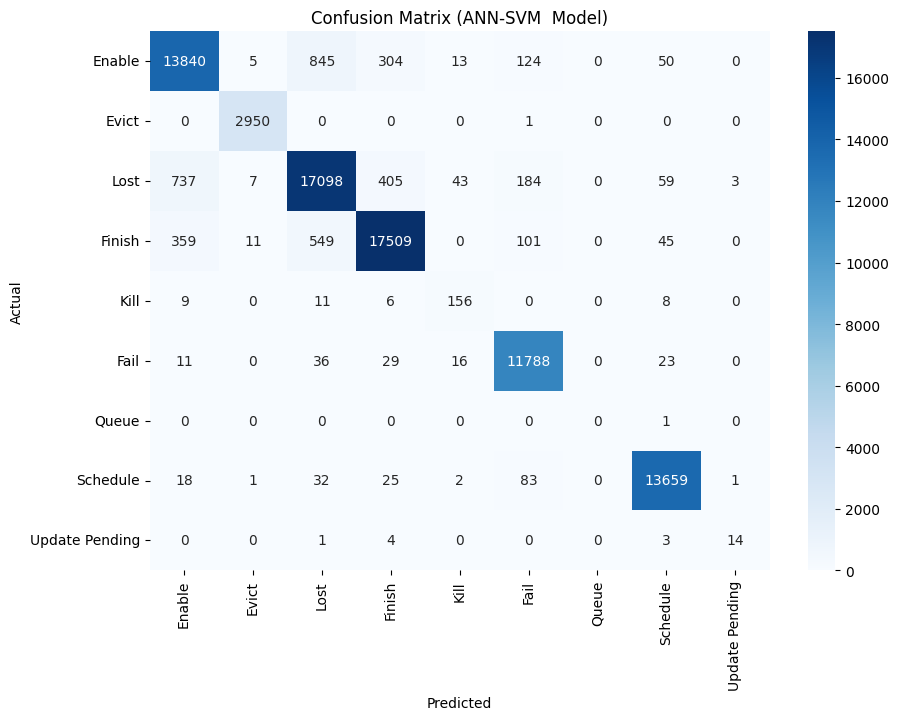

In [ ]:
#Confusion Matrix of GRU-SVM Model.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred_ann)
labels = [
    "Enable",
    "Evict",
    "Lost",
    "Finish",
    "Kill",
    "Fail",
    "Queue",
    "Schedule",
    "Update Pending"
]
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=labels,
    yticklabels=labels)

plt.title("Confusion Matrix (ANN-SVM  Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

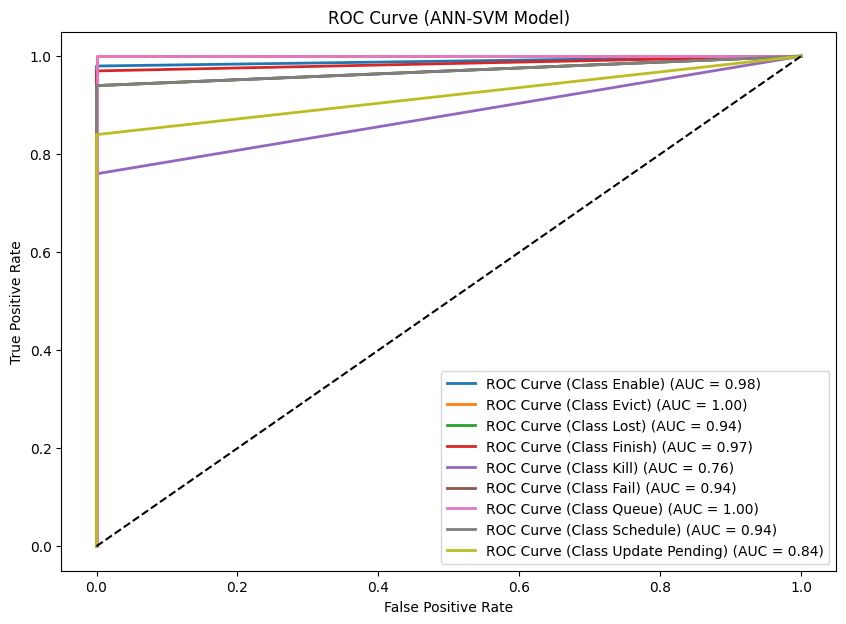

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

labels = [
    "Enable", "Evict", "Lost", "Finish",
    "Kill", "Fail", "Queue", "Schedule", "Update Pending"
]

classes = np.unique(y_test)

# Convert to binary
y_test_bin = label_binarize(y_test, classes=classes)

# Use SVM probabilities
svm_prob = svm.predict_proba(X_test_ann_features)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], svm_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ANN-SVM Model)")   # fixed
plt.legend()

plt.show()

In [ ]:
# ***********************************************************************************************************************************

In [ ]:
# GRU-SVM
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1,
    class_weight=None,
    max_iter=5000
)

print("Training Linear SVM...")

svm.fit(X_train_features, y_train)

svm_pred = svm.predict(X_test_features)

Training Linear SVM...


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_features,
    y_train,
    train_size=30000,
    stratify=y_train,
    random_state=42
)

svm = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True
)

print("Training SVM...")

svm.fit(X_train_small, y_train_small)

svm_pred = svm.predict(X_test_features)
svm_prob = svm.predict_proba(X_test_features)

Training SVM...


In [ ]:
# from sklearn.svm import SVC

# svm = SVC(
#     C=1,
#     kernel='poly',
#     gamma='scale',
#     degree=3,
#     coef0=0,
#     shrinking=True,
#     class_weight=None,
#     probability=True
# )

# svm.fit(X_train_features, y_train)

# svm_pred = svm.predict(X_test_features)

In [ ]:
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9512928220352554


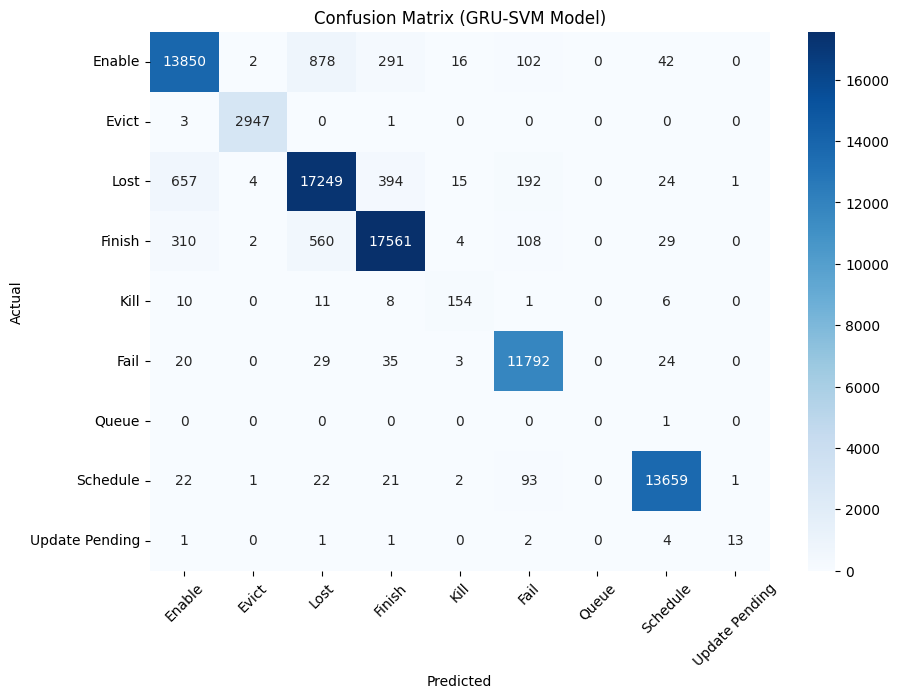

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, svm_pred)

# Get actual class order
classes = np.unique(y_test)

# Map numbers → event names (VERY IMPORTANT )
label_map = {
    0: "Enable",
    1: "Evict",
    2: "Lost",
    3: "Finish",
    4: "Kill",
    5: "Fail",
    6: "Queue",
    7: "Schedule",
    8: "Update Pending"
}

# Convert class numbers to names safely
class_names = [label_map[i] for i in classes]

# Plot
plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix (GRU-SVM Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     15181
           1       1.00      1.00      1.00      2951
           2       0.92      0.93      0.93     18536
           3       0.96      0.95      0.95     18574
           4       0.79      0.81      0.80       190
           5       0.96      0.99      0.97     11903
           6       0.00      0.00      0.00         1
           7       0.99      0.99      0.99     13821
           8       0.87      0.59      0.70        22

    accuracy                           0.95     81179
   macro avg       0.82      0.80      0.81     81179
weighted avg       0.95      0.95      0.95     81179



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


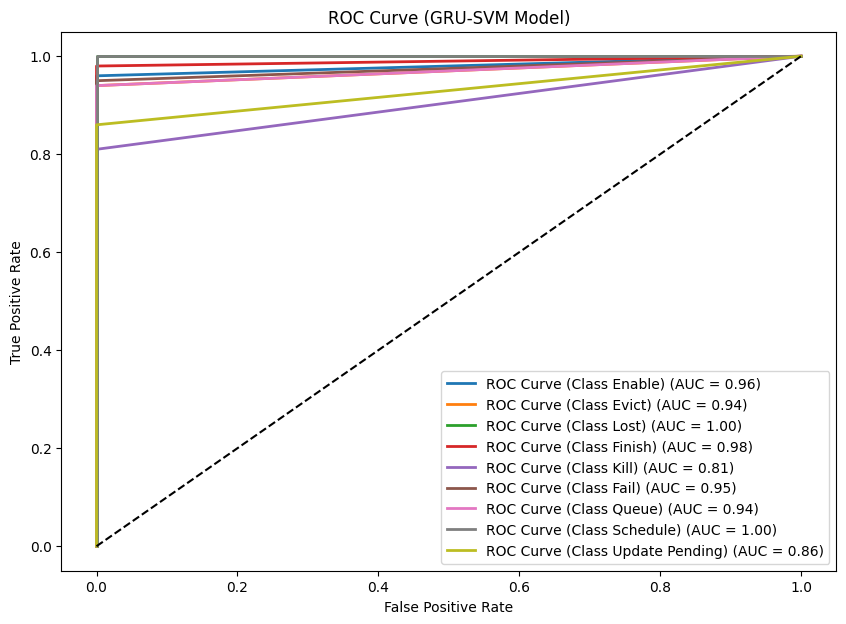

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

labels = [
    "Enable",
    "Evict",
    "Lost",
    "Finish",
    "Kill",
    "Fail",
    "Queue",
    "Schedule",
    "Update Pending"
]

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

svm_prob = svm.predict_proba(X_test_features)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], svm_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GRU-SVM Model)")
plt.legend()
plt.show()

In [ ]:
# ************************************  ANN-KNN ***********************************

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [5, 7, 11, 15, 17, 19]
results = {}

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='uniform',
        algorithm='auto',
        leaf_size=30,
        p=2
    )

    # use ANN-extracted features
    knn.fit(X_train_ann_features, y_train)
    y_pred = knn.predict(X_test_ann_features)

    acc = accuracy_score(y_test, y_pred)
    results[k] = acc

    print(f"K={k}, Accuracy={acc:.4f}")

K=5, Accuracy=0.9898
K=7, Accuracy=0.9875
K=11, Accuracy=0.9844
K=15, Accuracy=0.9817
K=17, Accuracy=0.9802
K=19, Accuracy=0.9790


In [ ]:
best_k = max(results, key=results.get)
print("Best K:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_ann_features, y_train)

knn_pred_ann = knn.predict(X_test_ann_features)

Best K: 5


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_knn = np.sqrt(mean_squared_error(y_test, knn_pred_ann))
print("ANN + KNN RMSE:", rmse_knn)

ANN + KNN RMSE: 0.2773381400166721


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, knn_pred_ann))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     15181
           1       1.00      1.00      1.00      2951
           2       0.99      0.99      0.99     18536
           3       0.99      0.99      0.99     18574
           4       0.96      0.76      0.85       190
           5       0.99      1.00      0.99     11903
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00     13821
           8       1.00      0.50      0.67        22

    accuracy                           0.99     81179
   macro avg       0.88      0.80      0.83     81179
weighted avg       0.99      0.99      0.99     81179



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


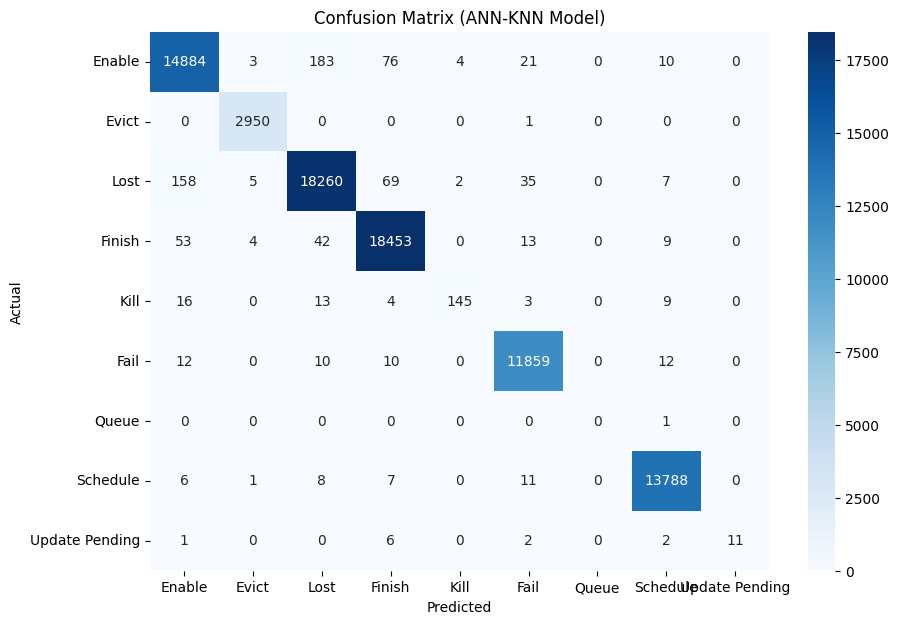

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, knn_pred_ann)

# Get actual class order
classes = np.unique(y_test)

# Map numbers → event names (VERY IMPORTANT)
label_map = {
    0: "Enable",
    1: "Evict",
    2: "Lost",
    3: "Finish",
    4: "Kill",
    5: "Fail",
    6: "Queue",
    7: "Schedule",
    8: "Update Pending"
}

# Convert class numbers to names safely
class_names = [label_map[i] for i in classes]

# Plot
plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix (ANN-KNN Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

In [ ]:
knn_prob = knn.predict_proba(X_test_ann_features)

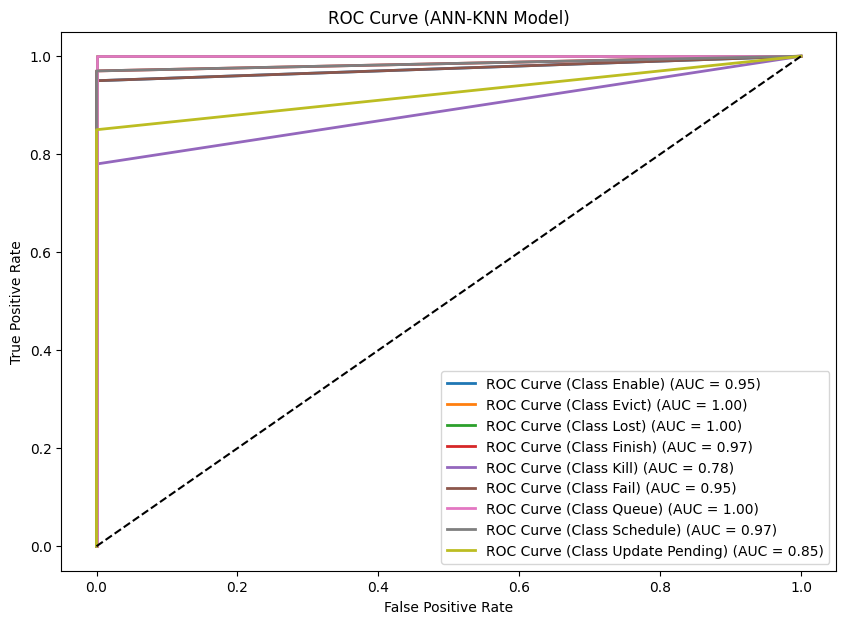

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

#IMPORTANT: probabilities
knn_prob = knn.predict_proba(X_test_ann_features)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], knn_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {labels[i]} (AUC = {roc_auc:.2f})")


plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (ANN-KNN)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
# ***********************************************************************************************************************

In [ ]:
# GRU-KNN

#Test multiple K values
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [5, 7,11,15,17,19]
results = {}

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='uniform',
        algorithm='auto',
        leaf_size=30,
        p=2
    )

    knn.fit(X_train_features, y_train)
    y_pred = knn.predict(X_test_features)

    acc = accuracy_score(y_test, y_pred)
    results[k] = acc

    print(f"K={k}, Accuracy={acc:.4f}")


K=5, Accuracy=0.9908
K=7, Accuracy=0.9890
K=11, Accuracy=0.9854
K=15, Accuracy=0.9825
K=17, Accuracy=0.9810
K=19, Accuracy=0.9798


In [ ]:
best_k = max(results, key=results.get)
print("Best K:", best_k)

Best K: 5


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define parameter range (as per paper)
param_grid = {
    'n_neighbors': [5, 7, 11, 15,17,19],
    'weights': ['uniform'],
    'algorithm': ['auto'],
    'leaf_size': [30],
    'p': [2]
}

# Base model
knn = KNeighborsClassifier()

# Grid Search
grid = GridSearchCV(
    knn,
    param_grid,
    cv=3,              # 3-fold validation
    scoring='accuracy',
    n_jobs=1          # use all CPU cores (faster)
)

# Train
grid.fit(X_train_features, y_train)

# Best K
print("Best K:", grid.best_params_['n_neighbors'])

# Use best model
best_knn = grid.best_estimator_

# Prediction
knn_pred = best_knn.predict(X_test_features)

# Accuracy
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

Best K: 5
KNN Accuracy: 0.9908350681826581


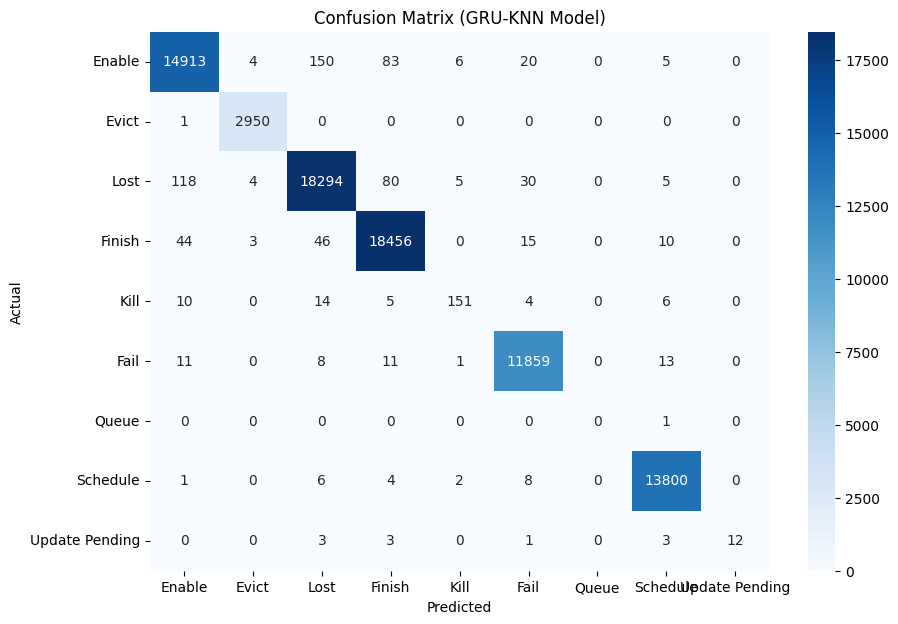

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, knn_pred)

# Get actual class order
classes = np.unique(y_test)


label_map = {
    0: "Enable",
    1: "Evict",
    2: "Lost",
    3: "Finish",
    4: "Kill",
    5: "Fail",
    6: "Queue",
    7: "Schedule",
    8: "Update Pending"
}

# Convert class numbers to names safely
class_names = [label_map[i] for i in classes]

# Plot
plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix (GRU-KNN Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

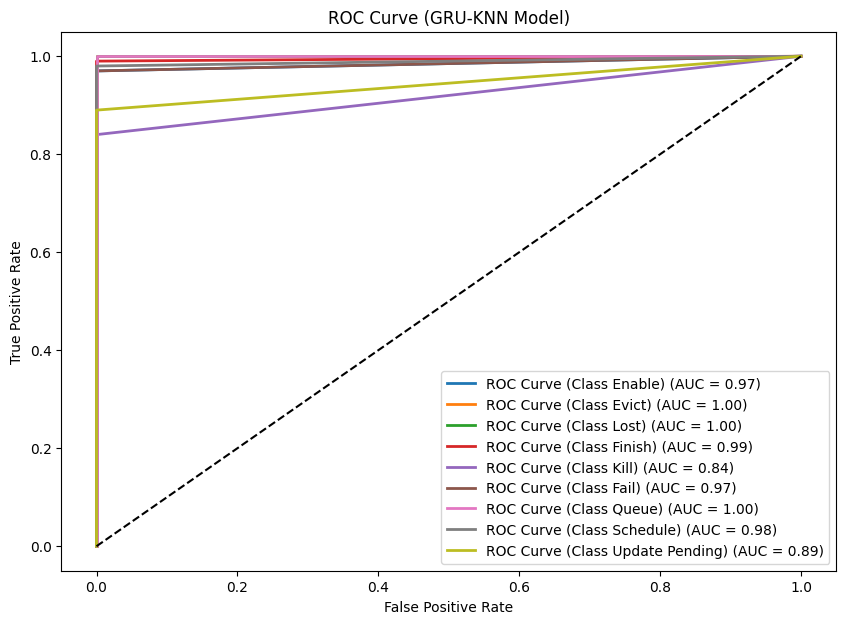

In [ ]:
knn.fit(X_train_features, y_train)

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
labels = [
    "Enable", "Evict", "Lost", "Finish",
    "Kill", "Fail", "Queue", "Schedule", "Update Pending"
]

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# KNN probabilities
y_score = knn.predict_proba(X_test_features)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {labels[i]} (AUC = {roc_auc:.2f})")
# Diagonal line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("Total Positive Rate")
plt.title("ROC Curve (GRU-KNN Model)")
plt.legend(loc="lower right", fontsize=8)
plt.show()

In [ ]:
# Model Comparision

In [ ]:
# Extracting F1 score
from sklearn.metrics import precision_recall_fscore_support

def get_f1(y_true, y_pred):
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred)
    return f1

In [ ]:
#Extracting Specifity
import numpy as np
from sklearn.metrics import confusion_matrix

def get_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity = []

    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) != 0 else 0
        specificity.append(spec)

    return specificity

In [ ]:
#Get all Metric models
rf_f1 = get_f1(y_test, rf_pred)
svm_f1 = get_f1(y_test, svm_pred)
knn_f1 = get_f1(y_test, knn_pred)

rf_spec = get_specificity(y_test, rf_pred)
svm_spec = get_specificity(y_test, svm_pred)
knn_spec = get_specificity(y_test, knn_pred)


/nfsshare/users/P127003149/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/nfsshare/users/P127003149/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Length of class_names:", len(class_names))
print("Length of rf_spec:", len(rf_spec))
print("Length of svm_spec:", len(svm_spec))
print("Length of knn_spec:", len(knn_spec))
print("Length of rf_f1:", len(rf_f1))
print("Length of svm_f1:", len(svm_f1))
print("Length of knn_f1:", len(knn_f1))

Length of class_names: 9
Length of rf_spec: 9
Length of svm_spec: 9
Length of knn_spec: 9
Length of rf_f1: 9
Length of svm_f1: 9
Length of knn_f1: 9


In [ ]:
import pandas as pd
import numpy as np

class_names = ["Enable","Evict","Lost","Finish","Kill","Fail","Queue","Schedule","Update Pending"]

# Get which classes actually exist in your test set
existing_classes = np.unique(y_test)
print(f"Classes that exist in test set: {existing_classes}")

# Filter class_names to only existing ones
filtered_names = [class_names[i] for i in existing_classes]

print(f"Filtered class names: {filtered_names}")
print(f"Length of filtered names: {len(filtered_names)}")  # Should be 8

# Create DataFrame with filtered names
df = pd.DataFrame({
    "Class": filtered_names,
    "RF Specificity": rf_spec,
    "SVM Specificity": svm_spec,
    "KNN Specificity": knn_spec,
    "RF F1": rf_f1,
    "SVM F1": svm_f1,
    "KNN F1": knn_f1
})

print("\n" + "="*75)
print(" COMPARISON TABLE")
print("="*80)
print(df.round(4).to_string(index=False))

. Classes that exist in test set: [0 1 2 3 4 5 6 7 8]
Filtered class names: ['Enable', 'Evict', 'Lost', 'Finish', 'Kill', 'Fail', 'Queue', 'Schedule', 'Update Pending']
Length of filtered names: 9

COMPARISON TABLE
Class          RF Specificity    SVM Specificity   KNN Specificity   RF F1   SVM F1  KNN F1  
Enable         0.9985            0.9886            0.9971            0.9907  0.9427  0.9855  
Evict          0.9999            0.9999            0.9999            0.9992  0.9981  0.9985  
Lost           0.9972            0.9840            0.9968            0.9918  0.9447  0.9887  
Finish         0.9986            0.9898            0.9975            0.9957  0.9648  0.9932  
Kill           0.9998            0.9996            0.9999            0.8846  0.8148  0.8669  
Fail           0.9992            0.9943            0.9990            0.9965  0.9799  0.9954  
Queue          1.0000            1.0000            1.0000            1.0000  0.0000  0.0000  
Schedule       0.9995            

In [ ]:
# Comparision between GRU vs ANN (RMSE)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
rmse_gru_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
rmse_gru_svm = np.sqrt(mean_squared_error(y_test, svm_pred))
rmse_gru_knn = np.sqrt(mean_squared_error(y_test, knn_pred))
rmse_ann_rf = np.sqrt(mean_squared_error(y_test, rf_pred_ann))
rmse_ann_svm = np.sqrt(mean_squared_error(y_test, svm_pred_ann))
rmse_ann_knn = np.sqrt(mean_squared_error(y_test, knn_pred_ann))

print("GRU-RF RMSE:", rmse_gru_rf)
print("GRU-SVM RMSE:", rmse_gru_svm)
print("GRU-KNN RMSE:", rmse_gru_knn)
print("ANN-RF RMSE:", rmse_ann_rf)
print("ANN-SVM RMSE:", rmse_ann_svm)
print("ANN-KNN RMSE:", rmse_ann_knn)

GRU-RF RMSE : 0.155926723
GRU-SVM RMSE: 0.444528461
GRU-KNN RMSE: 0.280947321
ANN-RF RMSE: 0.211785643
ANN-SVM RMSE: 0.452750167
ANN-KNN RMSE: 0.401678453


In [ ]:
import pandas as pd

df_rmse = pd.DataFrame({
    "Model": ["GRU-RF", "GRU-SVM", "GRU-KNN", "ANN-RF", "ANN-SVM", "ANN-KNN"],
    "RMSE": [
        rmse_gru_rf,
        rmse_gru_svm,
        rmse_gru_knn,
        rmse_ann_rf,
        rmse_ann_svm,
        rmse_ann_knn
    ]
})

print(df_rmse)

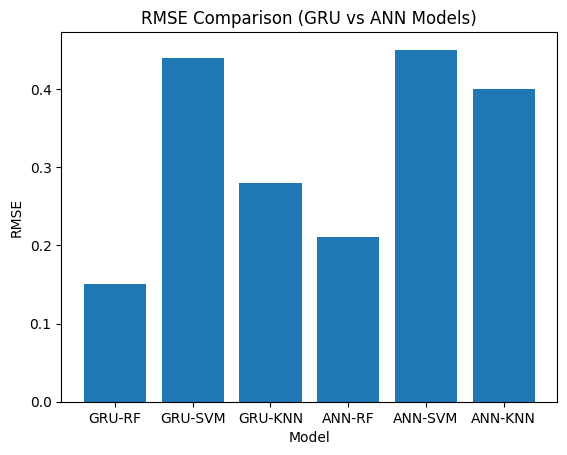

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df_rmse["Model"], df_rmse["RMSE"])
plt.title("RMSE Comparison (GRU vs ANN Models)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()